# <b><font color='chocolate'>Продвинутые возможности matplotlib. Часть 2</font></b>

### <font color='chocolate'>1. Визуализация данных, встроенная в pandas</font>

Метод <b>.plot()</b> поддерживает различные типы графиков через аргумент kind. Вот некоторые из наиболее часто используемых типов:
- <b>'line'</b> (линии): по умолчанию для индексированных данных.
- <b>'bar'</b> и <b>'barh'</b> (вертикальные и горизонтальные столбцы): для сравнения значений нескольких групп.
- <b>'hist'</b> (гистограмма): для визуализации распределения данных.
- <b>'box'</b> (ящик с усами): для отображения распределения по квартилям.
- <b>'scatter'</b> (точечная диаграмма): для визуализации взаимосвязей между двумя числовыми переменными.
- <b>'area'</b> (площадь): для стековых диаграмм, показывающих суммированное значение по времени или другим переменным.
- <b>'pie'</b> (круговая диаграмма): для отображения долевого соотношения категорий.


In [5]:
# мпорт бибилиотек
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [6]:
df = pd.DataFrame(np.random.randn(10, 4), columns=['A', 'B', 'C', 'D'])
df

,A,B,C,D
0,0.211597,1.232890,-1.680617,-0.197727
1,0.470690,-0.082302,-1.177434,0.658196
2,0.991384,2.494304,0.837459,-0.293942
3,-0.810609,-1.901666,-0.225693,-0.304874
4,-0.523249,-0.701798,0.331056,-0.262391
5,-0.706731,-1.610040,0.392278,-0.126402
6,0.292996,-0.086470,0.977943,-0.618648
7,0.751054,-0.872130,0.507888,0.379998
8,-0.320751,0.383560,1.445632,2.291678
9,-0.510257,1.232729,0.717275,-0.757360


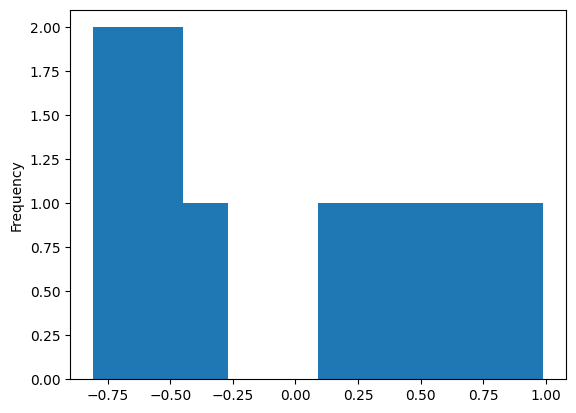

In [7]:
df['A'].plot(kind='hist')
plt.show()

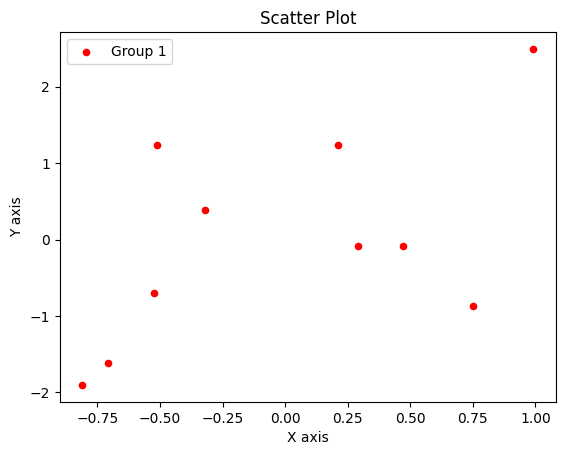

In [8]:
df.plot(kind='scatter', x='A', y='B', color='red', label='Group 1')
plt.title('Scatter Plot')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.legend()
plt.show()

##### <font color='chocolate'>1.1. Визуализация с использованием группировки.</font>

In [20]:
df = pd.DataFrame({'A': np.random.randint(1, 5, 10),
                   'B': np.random.rand(10)})
df

,A,B
0,1,0.346942
1,2,0.638048
2,3,0.713207
3,1,0.805057
4,3,0.285109
5,4,0.516366
6,4,0.548294
7,3,0.014449
8,3,0.313758
9,3,0.407082


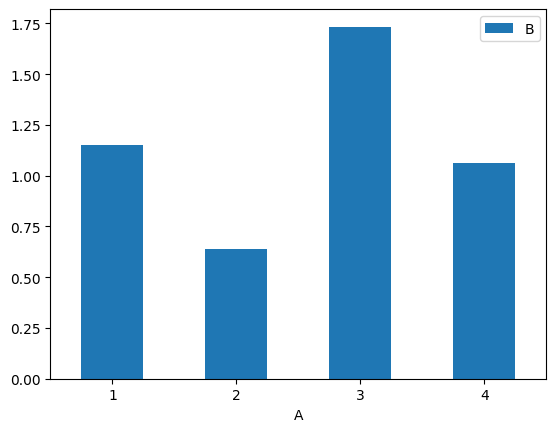

In [21]:
df.groupby('A').sum().plot(kind='bar')
plt.xticks(rotation = 0)
plt.show()

##### <font color='chocolate'>1.2. Задание</font>
Для датафрейма из предыдущего примера постройте круговую диаграмму для средних значений при группировке по значениям столбца А.

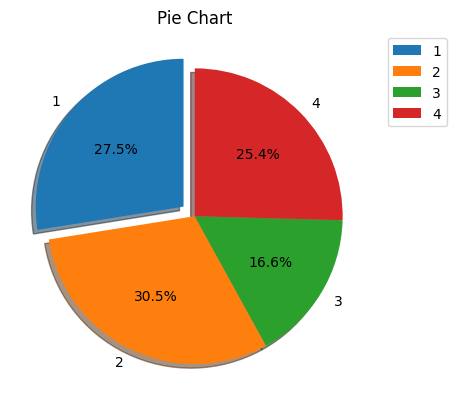

In [22]:
df.groupby('A').mean().plot(kind='pie', y='B', autopct='%1.1f%%', shadow=True, labels=df['A'].unique(), startangle=90, explode=(0.1, 0, 0, 0))
plt.legend(df['A'].unique(), loc='upper right', bbox_to_anchor=(1.20, 1))
plt.ylabel('')
plt.title('Pie Chart')
plt.show()

##### <font color='chocolate'>1.3. Создание сложных макетов</font>

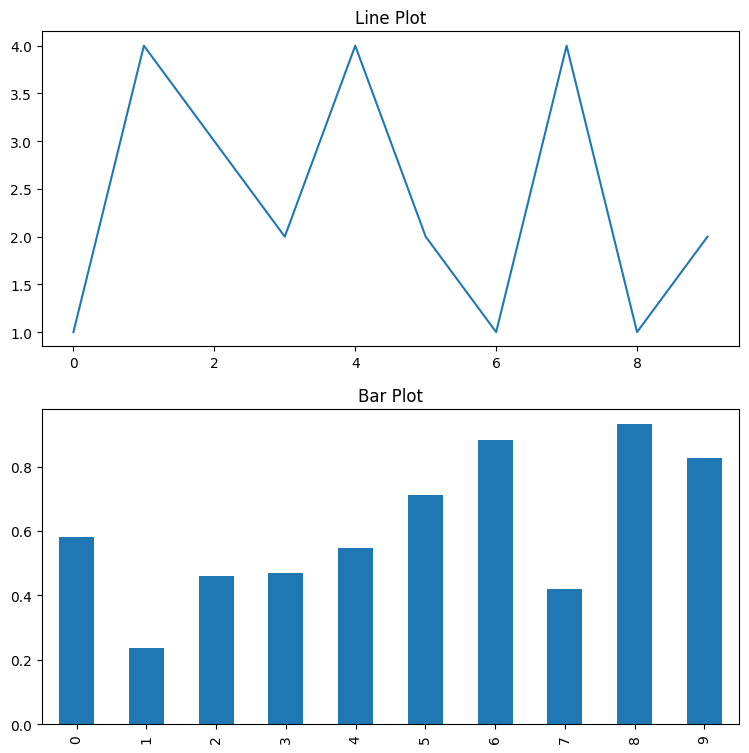

In [ ]:
fig, axes = plt.subplots(figsize=(9, 9), nrows=2, ncols=1) # эта функция объединяет plt.figure() и plt.subplot()
df['A'].plot(ax = axes[0], kind='line', title='Line Plot')
df['B'].plot(ax = axes[1], kind='bar', title='Bar Plot')
plt.show()

##### <font color='chocolate'>1.4. Стековые графики</font>

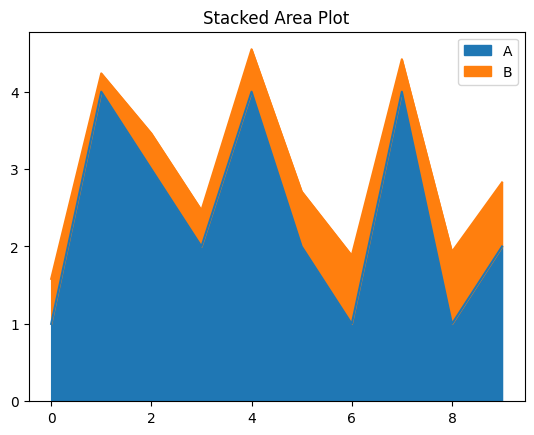

In [ ]:
df.plot(kind='area')
plt.title('Stacked Area Plot')
plt.show()

##### <font color='chocolate'>1.5. Задание</font>
На основе набора данных "data_sales.csv" постройте стековый график для определения вклада каждой страны в продажу каждого товара

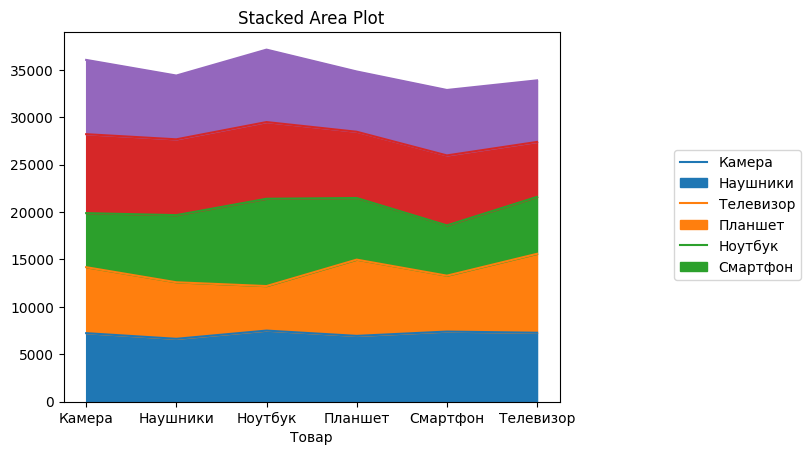

In [ ]:
df_sales = pd.read_csv('../data/sales_data (1).csv')
pd.crosstab(index=df_sales['Товар'], columns=df_sales['Страна'], values=df_sales['Количество'], aggfunc='sum')\
    .plot(kind='area')
plt.title('Stacked Area Plot')
plt.legend(df_sales['Товар'].unique(), loc='upper right', bbox_to_anchor=(1.5, 0.7))


##### <font color='chocolate'>1.6. Графики с разбивкой по категориям</font>

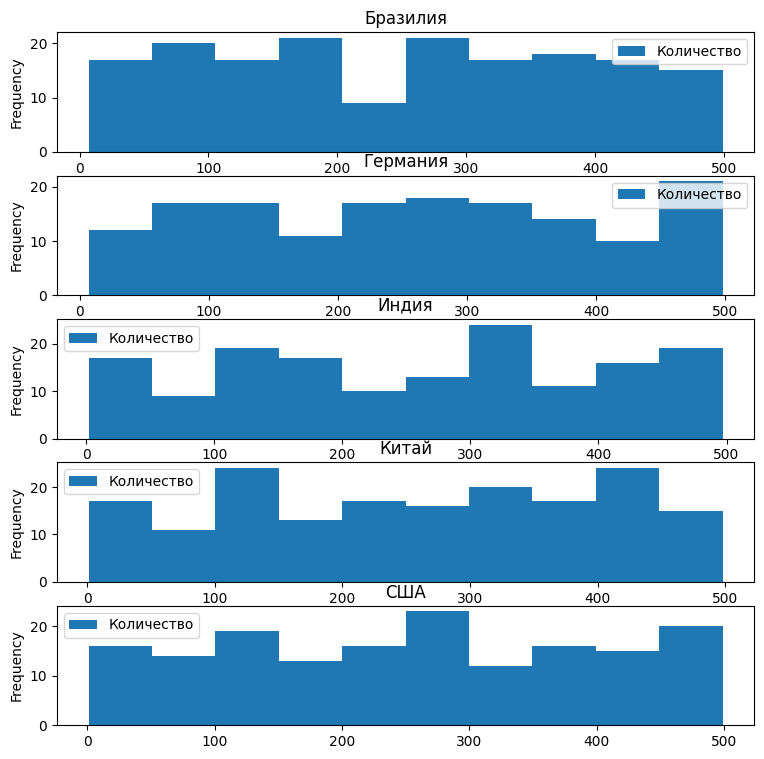

In [ ]:
df_sales.plot(kind="hist", figsize=(9, 9), column='Количество', by='Страна')
plt.show()

##### <font color='chocolate'>1.7. Парные графики и матрицы рассеяния</font>
Ответьте на вопросы: 
1. Какая связь между возрастом и артериальным давлением.
2. Как уровень холестерина связан с весом.
3. Есть ли корреляция между уровнем сахара и артериальным давлением.

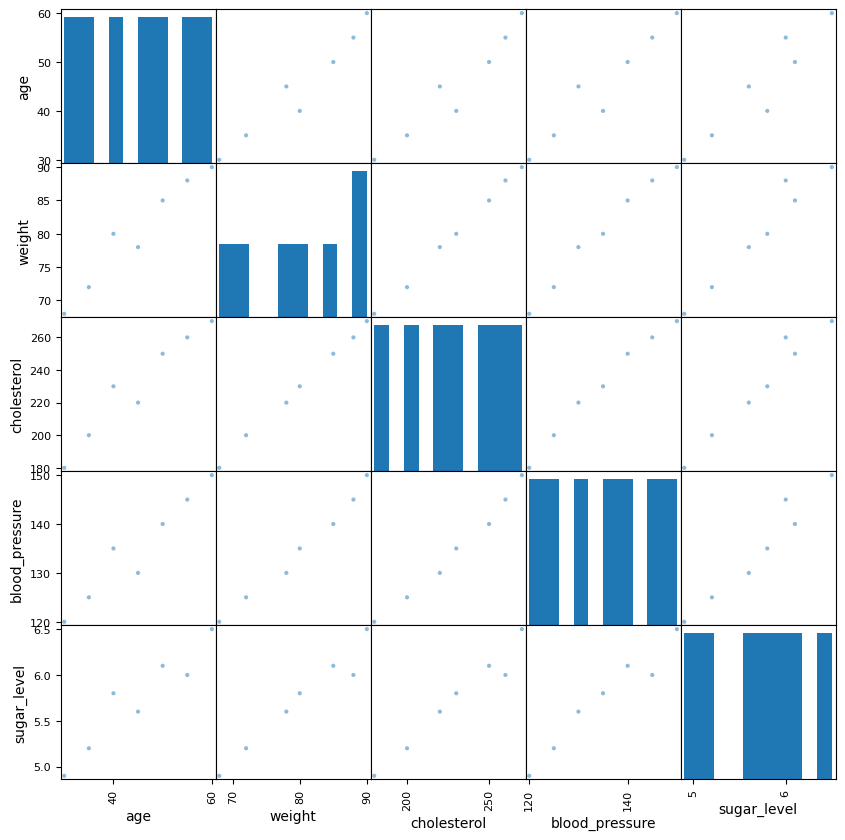

In [ ]:
from pandas.plotting import scatter_matrix
data = pd.DataFrame({
    'age': [45, 50, 30, 60, 35, 55, 40],
    'weight': [78, 85, 68, 90, 72, 88, 80],
    'cholesterol': [220, 250, 180, 270, 200, 260, 230],
    'blood_pressure': [130, 140, 120, 150, 125, 145, 135],
    'sugar_level': [5.6, 6.1, 4.9, 6.5, 5.2, 6.0, 5.8]
})
scatter_matrix(data, figsize=(10, 10))
plt.show()

##### <font color='chocolate'>1.8. Задание</font>
Для данных о средней температуре и количестве осадков в Берлине по месяцам<br>
temp = [1.8, 1.8, 4.8, 9.0, 14.0, 18.8, 19.8, 19.6, 15.0, 10.0, 5.0, 2.0]<br>
prec = [56, 41, 53, 42, 60, 67, 81, 62, 56, 49, 48, 54]<br>
создайте датафрейм и матрицу рассеяния для него.


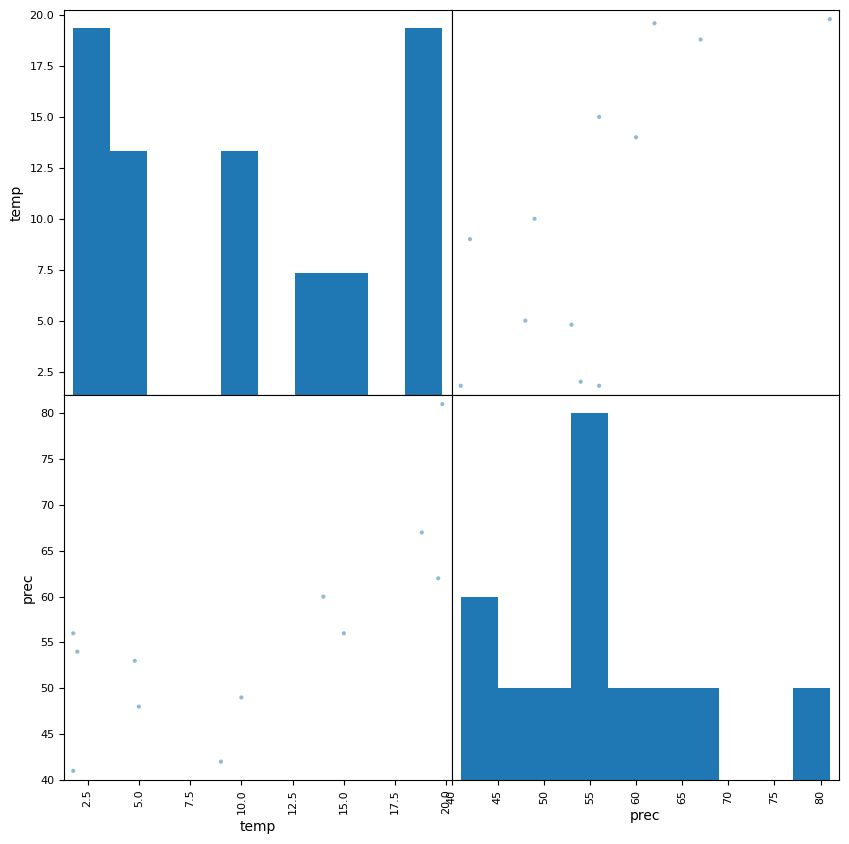

In [ ]:
temp = [1.8, 1.8, 4.8, 9.0, 14.0, 18.8, 19.8, 19.6, 15.0, 10.0, 5.0, 2.0]
prec = [56, 41, 53, 42, 60, 67, 81, 62, 56, 49, 48, 54]
data = pd.DataFrame({
    'temp': temp,
    'prec': prec
})
scatter_matrix(data, figsize=(10, 10))
plt.show()

### <font color='chocolate'>2. Работа с датасетом Titanic</font>

In [29]:
# Загрузка данных
df = pd.read_csv('../data/titanic.csv')
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


Посмотрим на распределение выживших и невыживших пассажиров среди тех, билет которых стоил менее 50 единиц.

array([<Axes: title={'center': '0'}, ylabel='Frequency'>,
       <Axes: title={'center': '1'}, ylabel='Frequency'>], dtype=object)

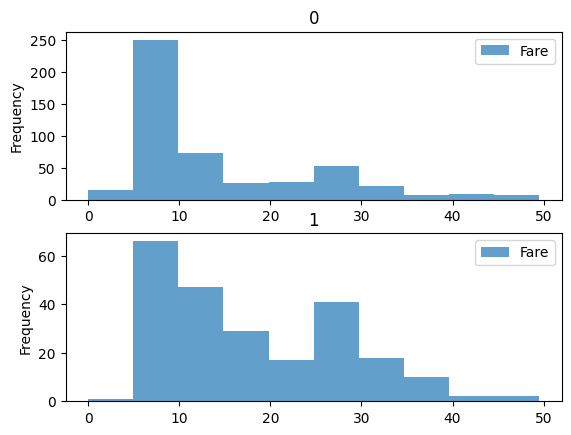

In [30]:
df[df['Fare'] < 50].plot(kind = 'hist', by = 'Survived', column = 'Fare', alpha = 0.7)

А теперь хотим посмотреть на то как распределены выжившие и невыжившие в зависимости от цены билета.

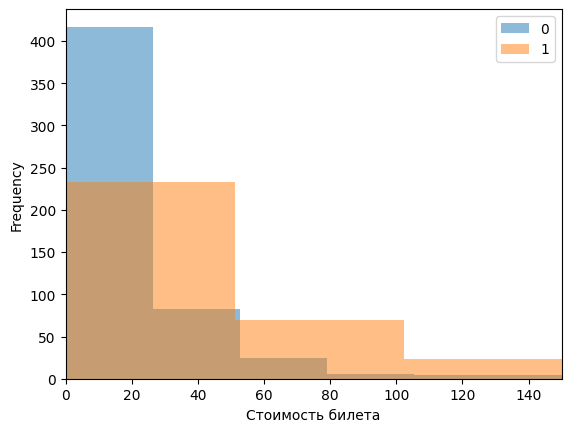

In [31]:
# groupby здесь не сводит данные к агрегатам, а просто "разделяет" их на подвыборки.
# Каждая подвыборка рисуется как отдельная гистограмма.
df.groupby('Survived').Fare.plot(kind="hist", alpha=0.5)
plt.xlim(0, 150)
plt.xlabel('Стоимость билета')
plt.legend()
plt.show()

Ту же информацию можно визуализировать с помощью ядерной оценки плотности (kde).

In [ ]:
!pip install scipy

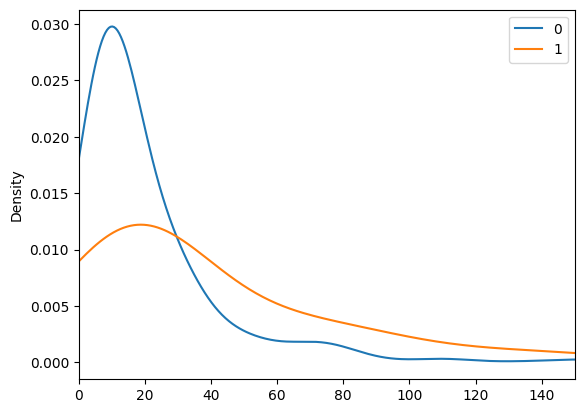

In [32]:
# Ось Y → плотность вероятности - вероятность, того, что человек выживет/не выживет
df.groupby('Survived').Fare.plot(kind="kde")
plt.xlim(0, 150)
plt.legend()
plt.show()

Посмотрим распределение цены

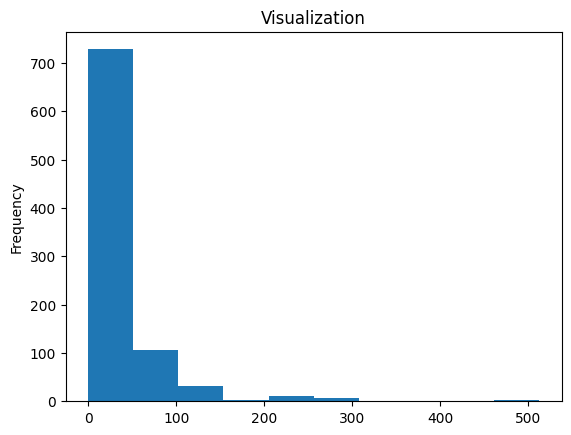

In [ ]:
ax = df.Fare.plot.hist()
ax.set_title('Visualization')
plt.show()

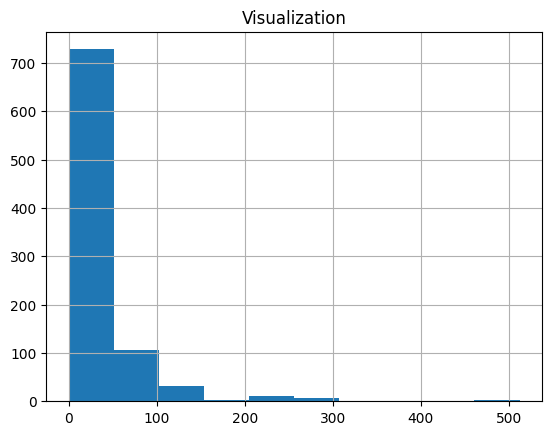

In [ ]:
ax = df.Fare.hist()
ax.set_title('Visualization')
plt.show()

### <font color='teal'>3. Решение задач</font>

<b> Задача №1 </b> <br>
Визуализировать распределение медианных цен на дома в датасете California Housing.

<i>Описание данных:</i>
- longitude - долгота.
- latitude - широта.
- housing_median_age - медианный возраст зданий (жилых домов) в районе.
- total_rooms - общее количество комнат во всех домах района.
- total_bedrooms - общее количество спален во всех домах района.
- population - численность населения района.
- households - количество домохозяйств в районе.
- median_income - медианный доход домохозяйства в районе.
- median_house_value - медианная стоимость жилья в районе.
- ocean_proximity - близость района к океану.
    - "NEAR BAY" — рядом с заливом,
    - "<1H OCEAN" — в пределах часа езды до океана,
    - "INLAND" — во внутренней части,
    - "NEAR OCEAN" — рядом с океаном,
    - "ISLAND" — на острове.

In [26]:
housing = pd.read_csv('../data/housing (1).csv')
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


Text(0, 0.5, 'Frequency')

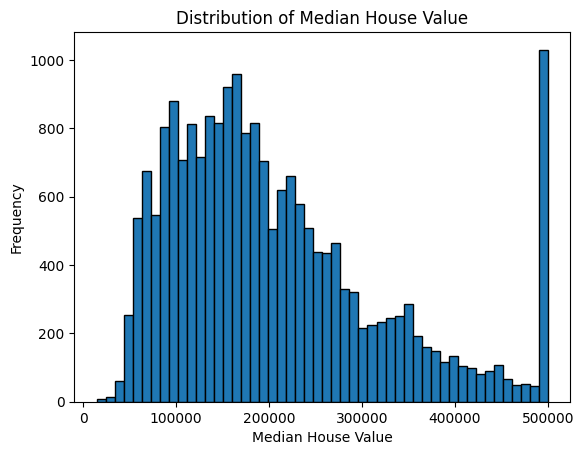

In [35]:
housing['median_house_value'].plot(kind='hist', bins=50, edgecolor='black')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

<b> Задача №2 </b> <br>
зучить взаимосвязь между общим количеством комнат и медианной ценой на жилье.

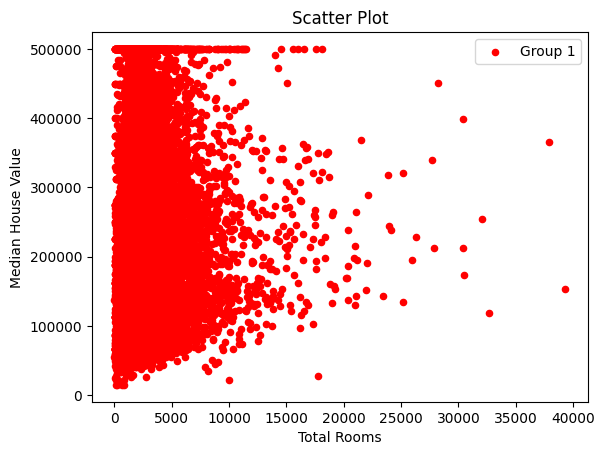

In [36]:
housing.plot(kind='scatter', x='total_rooms', y='median_house_value', color='red', label='Group 1')
plt.title('Scatter Plot')
plt.xlabel('Total Rooms')
plt.ylabel('Median House Value')
plt.legend()
plt.show()

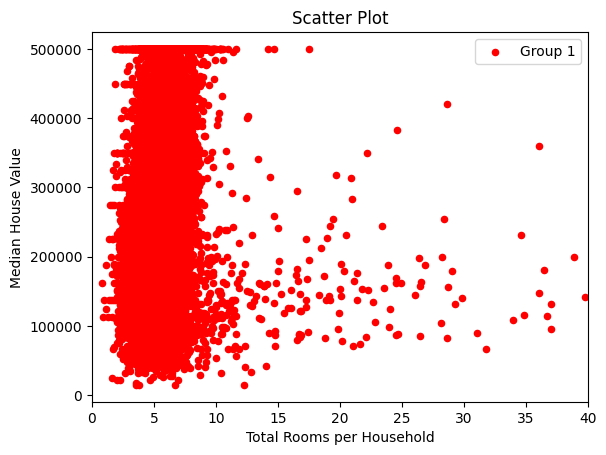

In [38]:
housing['house'] = housing['total_rooms'] / housing['households']
housing.plot(kind='scatter', x='house', y='median_house_value', color='red', label='Group 1')
plt.xlim(0, 40)
plt.title('Scatter Plot')
plt.xlabel('Total Rooms per Household')
plt.ylabel('Median House Value')
plt.legend()
plt.show()
